In [1]:
from pynhd import NLDI, NHDPlusHR
station_id = "02371500"
nldi = NLDI()
basin = nldi.get_basins(station_id)
 
basin_geom = basin.geometry.iloc[0]
 
hr_flw = NHDPlusHR(
    layer="flowline",
    outfields="*",   #
)
full_basin_02371500 = hr_flw.bygeom(basin_geom)
 
full_basin_02371500["bankfull"] = 1.2 * full_basin_02371500["qama"] # consider 20% increase in flow as bankfull
full_basin_02371500
# basin_geom

TypeError: 'NoneType' object is not iterable

In [2]:
import geopandas as gpd
from pathlib import Path

# your GeoDataFrame
gdf = full_basin_02371500

# output folder
output_dir = Path(r"F:\Github_repos\HydroLSTM-Audit\data")
output_dir.mkdir(parents=True, exist_ok=True)

# shapefile path
shp_path = output_dir / "NHDPlus_flowlines.shp"

# write shapefile
gdf.to_file(shp_path)

print(f"Shapefile written to: {shp_path}")

C:\Users\hdagne1\AppData\Local\Temp\ipykernel_15320\3732971304.py:15: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file(shp_path)


Shapefile written to: F:\Github_repos\HydroLSTM-Audit\data\NHDPlus_flowlines.shp


c:\Users\hdagne1\AppData\Local\anaconda3\envs\htamirud-dev\lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'permanent_identifier' to 'permanent_'
  ogr_write(
c:\Users\hdagne1\AppData\Local\anaconda3\envs\htamirud-dev\lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'wbarea_permanent_identifier' to 'wbarea_per'
  ogr_write(
c:\Users\hdagne1\AppData\Local\anaconda3\envs\htamirud-dev\lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'visibilityfilter' to 'visibility'
  ogr_write(
c:\Users\hdagne1\AppData\Local\anaconda3\envs\htamirud-dev\lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'Shape_Length' to 'Shape_Leng'
  ogr_write(


In [4]:
full_basin_02371500['nhdplusid']

0       15001200022539
1       15001200077678
2       15001200022729
3       15001200094063
4       15001200109647
             ...      
3643    15001200050237
3644    15001200107127
3645    15001200106788
3646    15001200036438
3647    15001200078203
Name: nhdplusid, Length: 3648, dtype: int64

In [3]:
full_basin_02371500.columns

Index(['geometry', 'OBJECTID', 'permanent_identifier', 'fdate', 'resolution',
       'gnis_id', 'gnis_name', 'lengthkm', 'reachcode', 'flowdir',
       'wbarea_permanent_identifier', 'ftype', 'fcode', 'mainpath',
       'innetwork', 'visibilityfilter', 'nhdplusid', 'vpuid', 'streamleve',
       'streamorde', 'streamcalc', 'fromnode', 'tonode', 'hydroseq',
       'levelpathi', 'pathlength', 'terminalpa', 'arbolatesu', 'divergence',
       'startflag', 'terminalfl', 'uplevelpat', 'uphydroseq', 'dnlevel',
       'dnlevelpat', 'dnhydroseq', 'dnminorhyd', 'dndraincou', 'frommeas',
       'tomeas', 'rtndiv', 'thinner', 'vpuin', 'vpuout', 'areasqkm',
       'totdasqkm', 'divdasqkm', 'maxelevraw', 'minelevraw', 'maxelevsmo',
       'minelevsmo', 'slope', 'slopelenkm', 'elevfixed', 'hwtype',
       'hwnodesqkm', 'statusflag', 'qama', 'vama', 'qincrama', 'qbma', 'vbma',
       'qincrbma', 'qcma', 'vcma', 'qincrcma', 'qdma', 'vdma', 'qincrdma',
       'qema', 'vema', 'qincrema', 'qfma', 'qincrfma

In [2]:
from rdflib import Graph, Namespace
HYDRO = Namespace("http://example.org/hydro/ontology#")

g = Graph()
g.parse("rdf/hydroKG.ttl", format="turtle")

print(len(list(g.subjects(None, HYDRO.Prediction))))

3


In [5]:
from rdflib import Graph, Namespace

HYDRO = Namespace("http://example.org/hydro/ontology#")

g = Graph()
g.parse("rdf/hydroKG.ttl", format="turtle")

print(len(list(g.subjects(None, HYDRO.Prediction))))

273953


In [6]:
from rdflib import Graph, Namespace, RDF

HYDRO = Namespace("http://example.org/hydro/ontology#")

g = Graph()
g.parse("rdf/hydroKG.ttl")

print("Observations:", len(list(g.subjects(RDF.type, HYDRO.Observation))))

Observations: 438270


In [7]:
from rdflib import Graph

ttl_path = r"F:\Github_repos\HydroLSTM-Audit\rdf\hydroKG.ttl"

g = Graph()
g.parse(ttl_path, format="turtle")

print("Total triples:", len(g))

Total triples: 5876969


In [8]:
from rdflib import RDF

query = """
SELECT ?class (COUNT(?s) AS ?count)
WHERE {
    ?s a ?class .
}
GROUP BY ?class
ORDER BY DESC(?count)
"""

for row in g.query(query):
    print(row)

(rdflib.term.URIRef('http://example.org/hydro/ontology#Observation'), rdflib.term.Literal('438270', datatype=rdflib.term.URIRef('http://www.w3.org/2001/XMLSchema#integer')))
(rdflib.term.URIRef('http://example.org/hydro/ontology#Prediction'), rdflib.term.Literal('273950', datatype=rdflib.term.URIRef('http://www.w3.org/2001/XMLSchema#integer')))
(rdflib.term.URIRef('http://example.org/hydro/ontology#TimeStep'), rdflib.term.Literal('14609', datatype=rdflib.term.URIRef('http://www.w3.org/2001/XMLSchema#integer')))
(rdflib.term.URIRef('http://example.org/hydro/ontology#Reach'), rdflib.term.Literal('3648', datatype=rdflib.term.URIRef('http://www.w3.org/2001/XMLSchema#integer')))
(rdflib.term.URIRef('http://example.org/hydro/ontology#Catchment'), rdflib.term.Literal('30', datatype=rdflib.term.URIRef('http://www.w3.org/2001/XMLSchema#integer')))
(rdflib.term.URIRef('http://www.w3.org/2002/07/owl#DatatypeProperty'), rdflib.term.Literal('15', datatype=rdflib.term.URIRef('http://www.w3.org/2001/

In [9]:
query = """
SELECT ?predicate (COUNT(*) AS ?count)
WHERE {
    ?s ?predicate ?o .
}
GROUP BY ?predicate
ORDER BY DESC(?count)
"""

for row in g.query(query):
    print(row)

(rdflib.term.URIRef('http://www.w3.org/1999/02/22-rdf-syntax-ns#type'), rdflib.term.Literal('730536', datatype=rdflib.term.URIRef('http://www.w3.org/2001/XMLSchema#integer')))
(rdflib.term.URIRef('http://example.org/hydro/ontology#forCatchment'), rdflib.term.Literal('438270', datatype=rdflib.term.URIRef('http://www.w3.org/2001/XMLSchema#integer')))
(rdflib.term.URIRef('http://example.org/hydro/ontology#hasTimeStep'), rdflib.term.Literal('438270', datatype=rdflib.term.URIRef('http://www.w3.org/2001/XMLSchema#integer')))
(rdflib.term.URIRef('http://example.org/hydro/ontology#hasSoilMoistureL3'), rdflib.term.Literal('438270', datatype=rdflib.term.URIRef('http://www.w3.org/2001/XMLSchema#integer')))
(rdflib.term.URIRef('http://example.org/hydro/ontology#hasSoilMoistureL2'), rdflib.term.Literal('438270', datatype=rdflib.term.URIRef('http://www.w3.org/2001/XMLSchema#integer')))
(rdflib.term.URIRef('http://example.org/hydro/ontology#hasAirTemperature'), rdflib.term.Literal('438270', datatype=

In [10]:
for i, triple in enumerate(g):
    print(triple)
    if i > 20:
        break

(rdflib.term.URIRef('http://example.org/hydro/ontology#Observation_01139000_10553'), rdflib.term.URIRef('http://example.org/hydro/ontology#forCatchment'), rdflib.term.URIRef('http://example.org/hydro/ontology#Catchment_01139000'))
(rdflib.term.URIRef('http://example.org/hydro/ontology#Observation_01031500_8214'), rdflib.term.URIRef('http://example.org/hydro/ontology#hasTimeStep'), rdflib.term.URIRef('http://example.org/hydro/ontology#TimeStep_2003-06-29'))
(rdflib.term.URIRef('http://example.org/hydro/ontology#Observation_01510000_1919'), rdflib.term.URIRef('http://example.org/hydro/ontology#hasSoilMoistureL3'), rdflib.term.Literal('0.38', datatype=rdflib.term.URIRef('http://www.w3.org/2001/XMLSchema#float')))
(rdflib.term.URIRef('http://example.org/hydro/ontology#Prediction_01333000_19970320'), rdflib.term.URIRef('http://example.org/hydro/ontology#hasStreamflow'), rdflib.term.Literal('1.2467934429813767', datatype=rdflib.term.URIRef('http://www.w3.org/2001/XMLSchema#float')))
(rdflib.

In [11]:
from rdflib import Namespace, RDF

HYDRO = Namespace("http://example.org/hydro/ontology#")

obs = list(g.subjects(RDF.type, HYDRO.Observation))

print("Total observations:", len(obs))
print("Example:", obs[:5])

Total observations: 438270
Example: [rdflib.term.URIRef('http://example.org/hydro/ontology#Observation_01022500_0'), rdflib.term.URIRef('http://example.org/hydro/ontology#Observation_01022500_1'), rdflib.term.URIRef('http://example.org/hydro/ontology#Observation_01022500_10'), rdflib.term.URIRef('http://example.org/hydro/ontology#Observation_01022500_100'), rdflib.term.URIRef('http://example.org/hydro/ontology#Observation_01022500_1000')]


In [12]:
obs = list(g.subjects(RDF.type, HYDRO.Observation))[0]

for p,o in g.predicate_objects(obs):
    print(p, ":", o)

http://www.w3.org/1999/02/22-rdf-syntax-ns#type : http://example.org/hydro/ontology#Observation
http://example.org/hydro/ontology#forCatchment : http://example.org/hydro/ontology#Catchment_01022500
http://example.org/hydro/ontology#hasAirTemperature : -16.5
http://example.org/hydro/ontology#hasDischarge : 1.27
http://example.org/hydro/ontology#hasPotentialEvaporation : 1.6
http://example.org/hydro/ontology#hasPrecipitation : 0.0
http://example.org/hydro/ontology#hasSoilMoistureL1 : 0.28
http://example.org/hydro/ontology#hasSoilMoistureL2 : 0.27
http://example.org/hydro/ontology#hasSoilMoistureL3 : 0.26
http://example.org/hydro/ontology#hasSolarRadiation : 53.8
http://example.org/hydro/ontology#hasTimeStep : http://example.org/hydro/ontology#TimeStep_1981-01-01


# Auditing:

In [13]:
import pandas as pd

path = r"F:\Github_repos\HydroLSTM-Audit\audit_results\physical_violations.csv"

df = pd.read_csv(path)

print("Total violations:", len(df))
df.head()

Total violations: 6054


,basin,date,qobs,qsim,constraint
0,1022500,2008-09-30,14.65,4.605268,LARGE_ERROR
1,1022500,2008-10-01,9.87,2.950850,LARGE_ERROR
2,1022500,2008-11-27,13.74,6.704650,LARGE_ERROR
3,1022500,2008-11-28,11.86,4.683215,LARGE_ERROR
4,1022500,2008-11-29,10.49,4.752740,LARGE_ERROR


# Summary of violations by rule

In [14]:
summary = (
    df.groupby("constraint")
      .size()
      .reset_index(name="violations")
      .sort_values("violations", ascending=False)
)

summary

,constraint,violations
0,LARGE_ERROR,3419
1,RUNOFF_RATIO_ANOMALY,2635


# Add percentage of violations

In [15]:
summary["percentage"] = 100 * summary["violations"] / summary["violations"].sum()
summary

,constraint,violations,percentage
0,LARGE_ERROR,3419,56.475058
1,RUNOFF_RATIO_ANOMALY,2635,43.524942


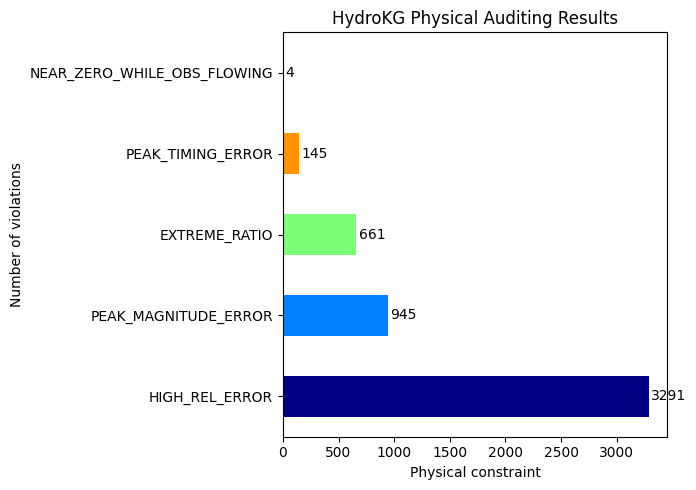

In [26]:
%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load results
path = r"F:\Github_repos\HydroLSTM-Audit\audit_results\physical_violations.csv"
df = pd.read_csv(path)

# Create summary
summary = (
    df.groupby("constraint")
      .size()
      .reset_index(name="violations")
      .sort_values("violations", ascending=False)
)

# Plot
fig, ax = plt.subplots(figsize=(7,5))

colors = plt.cm.jet(np.linspace(0, 1, len(summary)))

summary.plot.barh(
    x="constraint",
    y="violations",
    legend=False,
    color=colors,
    ax=ax
)

ax.set_ylabel("Number of violations")
ax.set_xlabel("Physical constraint")
ax.set_title("HydroKG Physical Auditing Results")

for i, v in enumerate(summary["violations"]):
    ax.text(v + 20, i, str(v), va="center")

plt.tight_layout()
plt.show()

In [74]:
# # Load results
# path = r"F:\Github_repos\HydroLSTM-Audit\audit_results\physical_violations.csv"
# df = pd.read_csv(path)
# df

In [63]:
df = pd.read_csv(r'F:\Github_repos\HydroLSTM-Audit\audit_results\physical_violations.csv')

In [73]:
all_basins = sorted(df["basin"].unique())
all_basins

[1022500,
 1031500,
 1047000,
 1052500,
 1054200,
 1055000,
 1057000,
 1078000,
 1134500,
 1137500,
 1139000,
 1144000,
 1169000,
 1170100,
 1181000,
 1333000,
 1350000,
 1365000,
 1413500,
 1423000,
 1435000,
 1439500,
 1440000,
 1440400,
 1451800,
 1485500,
 1487000,
 1491000,
 1510000,
 2371500]

C:\Users\hdagne1\AppData\Local\Temp\ipykernel_29576\2233828913.py:95: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  time_series = time_series.resample("M").sum()
C:\Users\hdagne1\AppData\Local\Temp\ipykernel_29576\2233828913.py:144: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


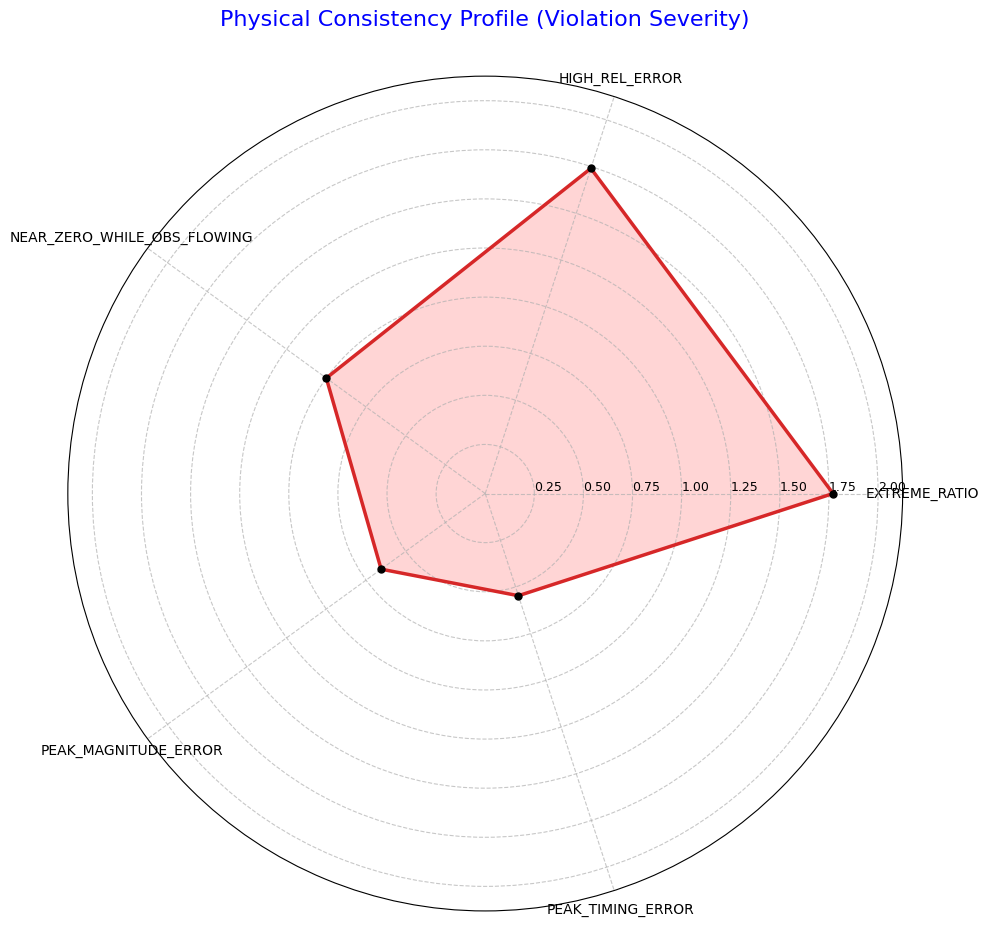

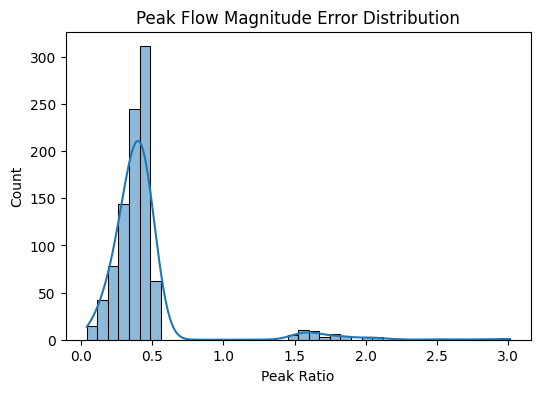

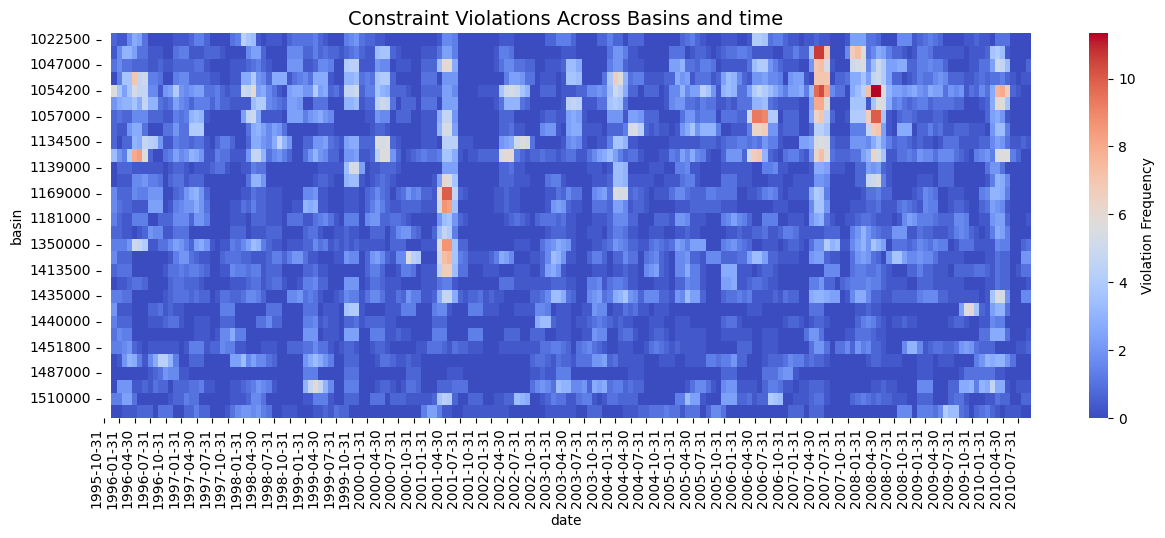

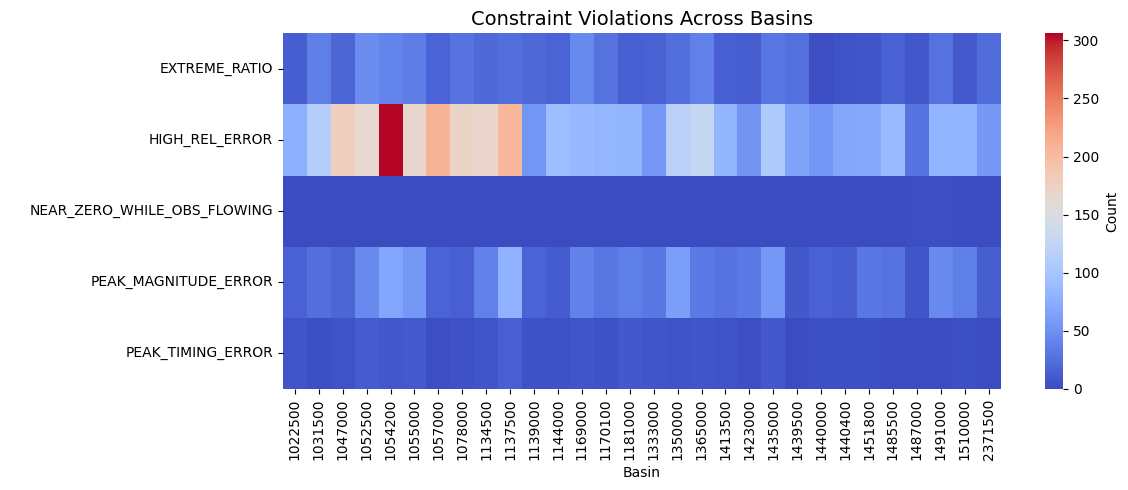

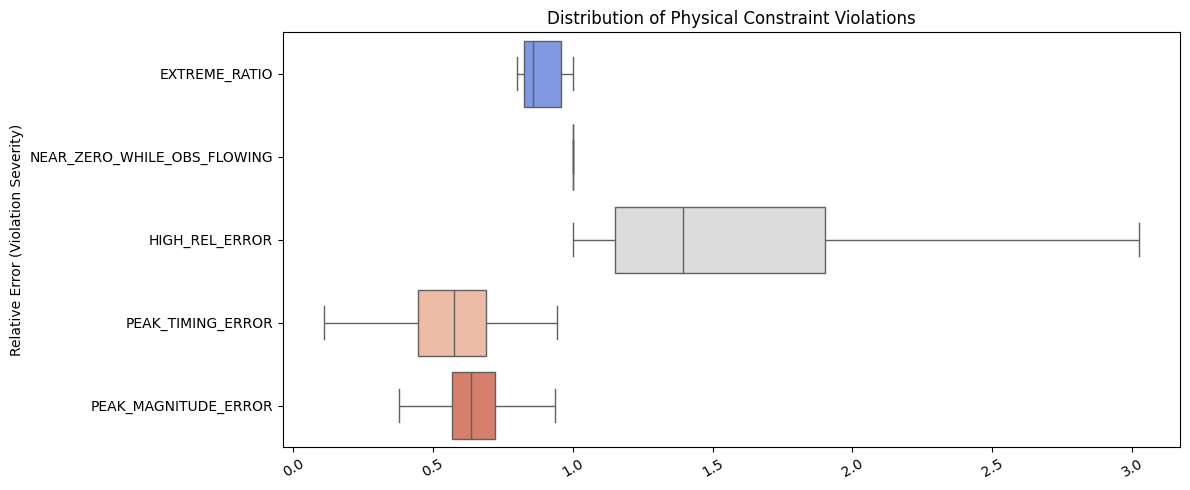

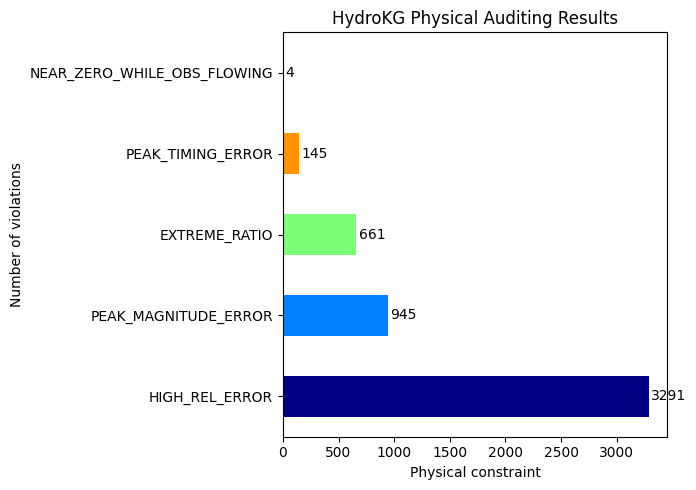

In [71]:
import numpy as np
import matplotlib.pyplot as plt


import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load results
df = pd.read_csv(r'F:\Github_repos\HydroLSTM-Audit\audit_results\physical_violations.csv')


summary = df.groupby("constraint").agg({
    "rel_err": "mean",
    "abs_err": "mean",
    "ratio": "mean"
})

labels = summary.index
values = summary["rel_err"].values

angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False)

values = np.concatenate([values, [values[0]]])
angles = np.concatenate([angles, [angles[0]]])

fig = plt.figure(figsize=(10,10))
ax = plt.subplot(111, polar=True)

# Use strong contrasting colors
line_color = "#d62728"   # red
fill_color = "#ff9896"   # light red

ax.plot(
    angles,
    values,
    color=line_color,
    linewidth=2.5
)

ax.fill(
    angles,
    values,
    color=fill_color,
    alpha=0.4
)

# Improve labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=10)

# Make radial grid clearer
ax.set_rlabel_position(0)
ax.tick_params(axis='y', labelsize=9)
ax.grid(True, linestyle='--', linewidth=0.8, alpha=0.7)

# Add reference circles
max_val = max(values)
ax.set_ylim(0, max_val * 1.2)

# Highlight key regions
for angle, val in zip(angles[:-1], values[:-1]):
    ax.scatter(angle, val, color="black", s=25, zorder=3)

# Title
ax.set_title(
    "Physical Consistency Profile (Violation Severity)\n",
    fontsize=16,
    pad=20,
    color='blue'
)

plt.tight_layout()


peak_df = df[df["constraint"] == "PEAK_MAGNITUDE_ERROR"]

fig, ax = plt.subplots(figsize=(6,4))

sns.histplot(
    peak_df["peak_ratio"],
    bins=40,
    kde=True,
    ax=ax
)

ax.set_title("Peak Flow Magnitude Error Distribution")
ax.set_xlabel("Peak Ratio")


df["date"] = pd.to_datetime(df["date"])

# Aggregate monthly
time_series = df.groupby(["date", "basin"]).size().unstack(fill_value=0)
time_series = time_series.resample("M").sum()

# Smooth (optional)
time_series_smooth = time_series.rolling(3).mean()

plt.figure(figsize=(15,5))

ax = sns.heatmap(
    time_series_smooth.T,
    cmap="coolwarm",
    cbar_kws={"label": "Violation Frequency"}
)

# Keep ALL ticks, just format them
xticks = ax.get_xticks()
ax.set_xticks(xticks)

ax.set_xticklabels(
    [time_series_smooth.index[int(i)].strftime("%Y-%m-%d") for i in xticks],
    rotation=90,
    ha="right"
)
plt.title("Constraint Violations Across Basins and time", fontsize=14)


pivot = pd.crosstab(df["basin"], df["constraint"]).T  # switch axes

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

sns.heatmap(
    pivot,
    cmap = "coolwarm",
    cbar_kws={"label": "Count"}
)

plt.title("Constraint Violations Across Basins", fontsize=14)
plt.xlabel("Basin")
plt.ylabel(" ")

plt.tight_layout()

import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12,5))

sns.boxplot(
    data=df,
    x="rel_err",
    y="constraint",
    palette="coolwarm",
    showfliers=False,
    ax=ax
)

ax.set_ylabel("Relative Error (Violation Severity)")
ax.set_xlabel("")
ax.set_title("Distribution of Physical Constraint Violations")

plt.xticks(rotation=30)
plt.tight_layout()


%matplotlib inline




# Create summary
summary = (
    df.groupby("constraint")
      .size()
      .reset_index(name="violations")
      .sort_values("violations", ascending=False)
)

# Plot
fig, ax = plt.subplots(figsize=(7,5))

colors = plt.cm.jet(np.linspace(0, 1, len(summary)))

summary.plot.barh(
    x="constraint",
    y="violations",
    legend=False,
    color=colors,
    ax=ax
)

ax.set_ylabel("Number of violations")
ax.set_xlabel("Physical constraint")
ax.set_title("HydroKG Physical Auditing Results")

for i, v in enumerate(summary["violations"]):
    ax.text(v + 20, i, str(v), va="center")

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Top Basins with Highest Physical Violations')

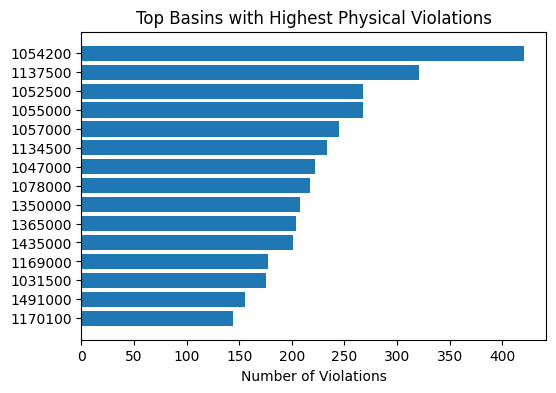

In [68]:
top = basin_summary.sort_values("violation_count", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(6,4))

ax.barh(top.index.astype(str), top["violation_count"])

ax.invert_yaxis()
ax.set_xlabel("Number of Violations")
ax.set_title("Top Basins with Highest Physical Violations")